# Tổng quan dữ liệu thời tiết

Notebook này dùng để kiểm tra nhanh dữ liệu trong `../data/database/weather_data.db`: số dòng, khoảng thời gian, chất lượng dữ liệu, phân phối các biến chính và một số xu hướng theo thời gian.

Các bảng hiển thị trong notebook sẽ dùng tên cột tiếng Việt để dễ đọc. Trong code, notebook vẫn giữ tên cột gốc như `temp`, `rhum`, `prcp` để tránh làm hỏng các bước xử lý hoặc notebook training đang có.

## 1. Thiết lập môi trường

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)

DB_PATH_CANDIDATES = [
    Path("../data/database/weather_data.db"),
    Path("data/database/weather_data.db"),
]
DB_PATH = next((path for path in DB_PATH_CANDIDATES if path.exists()), DB_PATH_CANDIDATES[0])
assert DB_PATH.exists(), f"Không tìm thấy database: {DB_PATH.resolve()}"

plt.style.use("seaborn-v0_8-whitegrid")

COLUMN_LABELS = {
    "time": "Thời gian",
    "city": "Thành phố",
    "station_id": "Mã trạm",
    "temp": "Nhiệt độ (°C)",
    "dwpt": "Điểm sương (°C)",
    "rhum": "Độ ẩm (%)",
    "prcp": "Lượng mưa (mm)",
    "snow": "Tuyết (mm)",
    "wdir": "Hướng gió (độ)",
    "wspd": "Tốc độ gió (km/h)",
    "wpgt": "Gió giật (km/h)",
    "pres": "Áp suất (hPa)",
    "tsun": "Nắng (phút)",
    "cldc": "Mây che phủ (%)",
    "coco": "Mã thời tiết",
    "hour": "Giờ",
    "month": "Tháng",
    "hour_sin": "Giờ sin",
    "hour_cos": "Giờ cos",
    "month_sin": "Tháng sin",
    "month_cos": "Tháng cos",
}

COLUMN_DESCRIPTIONS = {
    "time": "Mốc thời gian của bản ghi, theo từng giờ.",
    "city": "Tên thành phố: Hà Nội, Đà Nẵng hoặc TP HCM.",
    "station_id": "Mã trạm khí tượng Meteostat đại diện cho thành phố.",
    "temp": "Nhiệt độ không khí, thường là biến mục tiêu chính khi dự báo thời tiết.",
    "rhum": "Độ ẩm tương đối. Giá trị càng cao thì không khí càng ẩm.",
    "prcp": "Lượng mưa trong khoảng thời gian quan sát. Giá trị 0 nghĩa là không mưa.",
    "snow": "Lượng tuyết. Với dữ liệu Việt Nam, cột này thường ít hoặc không có ý nghĩa thực tế.",
    "wdir": "Hướng gió tính theo độ, từ 0 đến 360.",
    "wspd": "Tốc độ gió trung bình.",
    "pres": "Áp suất khí quyển. Biến này có thể liên quan đến thay đổi thời tiết.",
    "coco": "Mã điều kiện thời tiết do Meteostat cung cấp.",
    "hour_sin": "Biểu diễn chu kỳ giờ trong ngày bằng sin, giúp mô hình hiểu 23h gần 0h.",
    "hour_cos": "Biểu diễn chu kỳ giờ trong ngày bằng cos.",
    "month_sin": "Biểu diễn chu kỳ tháng trong năm bằng sin, giúp mô hình học mùa vụ.",
    "month_cos": "Biểu diễn chu kỳ tháng trong năm bằng cos.",
}

def ten_cot(cot):
    if cot in COLUMN_LABELS:
        return COLUMN_LABELS[cot]
    if "_lag_" in cot:
        bien, do_tre = cot.split("_lag_")
        return f"{COLUMN_LABELS.get(bien, bien)} trễ {do_tre.replace('h', ' giờ')}"
    if "_roll_mean_" in cot:
        bien, cua_so = cot.split("_roll_mean_")
        return f"Trung bình {COLUMN_LABELS.get(bien, bien)} {cua_so.replace('h', ' giờ')}"
    if "_roll_std_" in cot:
        bien, cua_so = cot.split("_roll_std_")
        return f"Độ lệch chuẩn {COLUMN_LABELS.get(bien, bien)} {cua_so.replace('h', ' giờ')}"
    return cot

def hien_thi_tieng_viet(dataframe):
    return dataframe.rename(columns={col: ten_cot(col) for col in dataframe.columns})

DB_PATH.resolve()

/Users/quangnguyentamhuu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


PosixPath('/Users/quangnguyentamhuu/Desktop/XayDungHeThongDuBaoThoiTiet/data/database/weather_data.db')

## 2. Từ điển cột dữ liệu

Bảng này giải thích ý nghĩa các cột quan trọng. Các cột dạng `trễ` là giá trị của biến ở những giờ trước đó, ví dụ `temp_lag_24h` là nhiệt độ trước 24 giờ. Các cột dạng `trung bình` hoặc `độ lệch chuẩn` là đặc trưng rolling, dùng để mô tả xu hướng gần đây của dữ liệu.

In [2]:
tu_dien_cot = pd.DataFrame(
    [
        {
            "Tên cột gốc": col,
            "Tên tiếng Việt": ten_cot(col),
            "Giải thích": COLUMN_DESCRIPTIONS.get(col, "Đặc trưng được tạo trong bước tiền xử lý hoặc dùng cho mô hình."),
        }
        for col in COLUMN_LABELS
    ]
)
tu_dien_cot

,Tên cột gốc,Tên tiếng Việt,Giải thích
0,time,Thời gian,"Mốc thời gian của bản ghi, theo từng giờ."
1,city,Thành phố,"Tên thành phố: Hà Nội, Đà Nẵng hoặc TP HCM."
2,station_id,Mã trạm,Mã trạm khí tượng Meteostat đại diện cho thành...
3,temp,Nhiệt độ (°C),"Nhiệt độ không khí, thường là biến mục tiêu ch..."
4,dwpt,Điểm sương (°C),Đặc trưng được tạo trong bước tiền xử lý hoặc ...
5,rhum,Độ ẩm (%),Độ ẩm tương đối. Giá trị càng cao thì không kh...
6,prcp,Lượng mưa (mm),Lượng mưa trong khoảng thời gian quan sát. Giá...
7,snow,Tuyết (mm),"Lượng tuyết. Với dữ liệu Việt Nam, cột này thư..."
8,wdir,Hướng gió (độ),"Hướng gió tính theo độ, từ 0 đến 360."
9,wspd,Tốc độ gió (km/h),Tốc độ gió trung bình.


## 3. Các bảng trong database

Database có thể chứa nhiều bảng. Bảng `hourly_weather` là dữ liệu thô theo giờ, còn `processed_weather` là dữ liệu đã được xử lý để huấn luyện mô hình. Hai bảng `predictions_history` và `error_history` thường dùng cho backend lưu lịch sử dự báo và sai số sau khi hệ thống chạy.

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query(
        """
        SELECT name AS table_name
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
        """,
        conn,
    )

    row_counts = []
    for table_name in tables["table_name"]:
        count = pd.read_sql_query(f"SELECT COUNT(*) AS rows FROM {table_name}", conn).iloc[0, 0]
        row_counts.append({"table_name": table_name, "rows": count})

pd.DataFrame(row_counts).rename(
    columns={"table_name": "Tên bảng", "rows": "Số dòng"}
).sort_values("Số dòng", ascending=False)

,Tên bảng,Số dòng
1,hourly_weather,273010
3,processed_weather,272968
2,predictions_history,156
0,error_history,153


## 4. Tải dữ liệu chính

Ưu tiên dùng bảng `processed_weather` vì bảng này đã có thêm đặc trưng thời gian, lag và rolling dùng cho mô hình. Nếu muốn xem dữ liệu thô, đổi `TABLE_NAME` thành `hourly_weather`.

Sau khi tải, dữ liệu được sắp xếp theo `Thành phố` và `Thời gian` để các biểu đồ chuỗi thời gian đọc đúng thứ tự.

In [4]:
TABLE_NAME = "processed_weather"

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn, parse_dates=["time"])

df = df.sort_values(["city", "time"]).reset_index(drop=True)
hien_thi_tieng_viet(df.head())

,Thời gian,Thành phố,Mã trạm,Nhiệt độ (°C),Độ ẩm (%),Lượng mưa (mm),Tuyết (mm),Hướng gió (độ),Tốc độ gió (km/h),Áp suất (hPa),Mã thời tiết,Giờ,Tháng,Giờ sin,Giờ cos,Tháng sin,Tháng cos,Nhiệt độ (°C) trễ 1 giờ,Nhiệt độ (°C) trễ 2 giờ,Nhiệt độ (°C) trễ 3 giờ,Nhiệt độ (°C) trễ 6 giờ,Nhiệt độ (°C) trễ 12 giờ,Nhiệt độ (°C) trễ 24 giờ,Độ ẩm (%) trễ 1 giờ,Độ ẩm (%) trễ 2 giờ,Độ ẩm (%) trễ 3 giờ,Độ ẩm (%) trễ 6 giờ,Độ ẩm (%) trễ 12 giờ,Độ ẩm (%) trễ 24 giờ,Lượng mưa (mm) trễ 1 giờ,Lượng mưa (mm) trễ 2 giờ,Lượng mưa (mm) trễ 3 giờ,Lượng mưa (mm) trễ 6 giờ,Lượng mưa (mm) trễ 12 giờ,Lượng mưa (mm) trễ 24 giờ,Tốc độ gió (km/h) trễ 1 giờ,Tốc độ gió (km/h) trễ 2 giờ,Tốc độ gió (km/h) trễ 3 giờ,Tốc độ gió (km/h) trễ 6 giờ,Tốc độ gió (km/h) trễ 12 giờ,Tốc độ gió (km/h) trễ 24 giờ,Trung bình Nhiệt độ (°C) 6 giờ,Độ lệch chuẩn Nhiệt độ (°C) 6 giờ,Trung bình Nhiệt độ (°C) 24 giờ,Độ lệch chuẩn Nhiệt độ (°C) 24 giờ,Trung bình Độ ẩm (%) 6 giờ,Độ lệch chuẩn Độ ẩm (%) 6 giờ,Trung bình Độ ẩm (%) 24 giờ,Độ lệch chuẩn Độ ẩm (%) 24 giờ
0,2016-01-02 00:00:00,Da Nang,48855,21.800,89.000,0.000,0.000,320.000,3.600,1020.800,5,0,1,0.000,1.000,0.500,0.866,22.000,21.000,21.500,22.400,22.700,22.900,88.000,94.000,93.000,89.000,86.000,81.000,0.000,0.000,0.000,0.000,0.000,0.000,7.600,5.400,3.600,3.600,0.000,3.600,21.717,0.402,23.096,1.393,91.000,2.966,84.667,7.013
1,2016-01-02 01:00:00,Da Nang,48855,23.000,83.000,0.000,0.000,0.000,0.000,1022.000,7,1,1,0.259,0.966,0.500,0.866,21.800,22.000,21.000,22.000,22.000,24.000,89.000,88.000,94.000,94.000,88.000,78.000,0.000,0.000,0.000,0.000,0.000,0.000,3.600,7.600,5.400,7.600,9.400,11.200,21.883,0.665,23.054,1.380,89.167,3.971,84.875,6.880
2,2016-01-02 02:00:00,Da Nang,48855,23.000,83.000,0.000,0.000,360.000,7.600,1021.000,7,2,1,0.500,0.866,0.500,0.866,23.000,21.800,22.000,22.000,23.000,25.000,83.000,89.000,88.000,88.000,83.000,74.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.600,7.600,7.600,11.200,11.200,22.050,0.809,22.971,1.316,88.333,4.719,85.250,6.496
3,2016-01-02 03:00:00,Da Nang,48855,22.700,85.000,0.000,0.000,360.000,0.000,1021.700,7,3,1,0.707,0.707,0.500,0.866,23.000,23.000,21.800,21.500,22.500,25.500,83.000,83.000,89.000,93.000,88.000,72.000,0.000,0.000,0.000,0.000,0.000,0.000,7.600,0.000,3.600,3.600,0.000,7.200,22.250,0.794,22.854,1.201,87.000,4.243,85.792,5.853
4,2016-01-02 04:00:00,Da Nang,48855,23.000,83.000,0.000,0.000,340.000,7.600,1019.000,7,4,1,0.866,0.500,0.500,0.866,22.700,23.000,23.000,21.000,22.000,25.000,85.000,83.000,83.000,94.000,94.000,78.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.600,0.000,5.400,7.600,18.400,22.583,0.546,22.771,1.112,85.167,2.714,86.000,5.649


In [5]:
overview = pd.DataFrame(
    {
        "Chỉ số": [
            "Số dòng",
            "Số cột",
            "Số thành phố",
            "Thời gian bắt đầu",
            "Thời gian kết thúc",
            "Dòng trùng mã trạm và thời gian",
        ],
        "Giá trị": [
            len(df),
            df.shape[1],
            df["city"].nunique(),
            df["time"].min(),
            df["time"].max(),
            df.duplicated(["station_id", "time"]).sum(),
        ],
    }
)
overview

,Chỉ số,Giá trị
0,Số dòng,272968
1,Số cột,49
2,Số thành phố,3
3,Thời gian bắt đầu,2016-01-02 00:00:00
4,Thời gian kết thúc,2026-05-23 08:00:00
5,Dòng trùng mã trạm và thời gian,0


Bảng trên cho biết dữ liệu đang bao phủ bao nhiêu bản ghi, bao nhiêu thành phố và kéo dài từ thời điểm nào đến thời điểm nào. Chỉ số `Dòng trùng mã trạm và thời gian` nên bằng 0; nếu lớn hơn 0 thì cùng một trạm có nhiều bản ghi ở cùng một giờ, dễ gây sai lệch khi huấn luyện mô hình.

## 5. Tóm tắt theo thành phố

Phần này giúp so sánh nhanh ba khu vực. Ví dụ, nhiệt độ trung bình cho biết thành phố nào nóng hơn trong toàn bộ giai đoạn dữ liệu; tổng lượng mưa cho biết thành phố nào có nhiều quan sát mưa hơn; tốc độ gió trung bình giúp nhận diện khác biệt về điều kiện gió.

In [6]:
city_summary = (
    df.groupby("city")
    .agg(
        rows=("time", "size"),
        start_time=("time", "min"),
        end_time=("time", "max"),
        avg_temp=("temp", "mean"),
        min_temp=("temp", "min"),
        max_temp=("temp", "max"),
        avg_rhum=("rhum", "mean"),
        total_prcp=("prcp", "sum"),
        avg_wspd=("wspd", "mean"),
    )
    .reset_index()
)
city_summary.rename(
    columns={
        "city": "Thành phố",
        "rows": "Số dòng",
        "start_time": "Bắt đầu",
        "end_time": "Kết thúc",
        "avg_temp": "Nhiệt độ TB (°C)",
        "min_temp": "Nhiệt độ thấp nhất (°C)",
        "max_temp": "Nhiệt độ cao nhất (°C)",
        "avg_rhum": "Độ ẩm TB (%)",
        "total_prcp": "Tổng lượng mưa (mm)",
        "avg_wspd": "Tốc độ gió TB (km/h)",
    }
)

,Thành phố,Số dòng,Bắt đầu,Kết thúc,Nhiệt độ TB (°C),Nhiệt độ thấp nhất (°C),Nhiệt độ cao nhất (°C),Độ ẩm TB (%),Tổng lượng mưa (mm),Tốc độ gió TB (km/h)
0,Da Nang,90929,2016-01-02,2026-05-23 08:00:00,26.749,13.000,41.000,78.872,10083.000,6.888
1,Ha Noi,91022,2016-01-02,2026-05-23 08:00:00,24.710,6.000,41.000,78.351,8223.500,10.162
2,TP HCM,91017,2016-01-02,2026-05-23 08:00:00,28.445,18.000,39.000,77.066,8287.000,10.112


## 6. Kiểm tra thiếu dữ liệu

Thiếu dữ liệu là vấn đề quan trọng trong dự báo thời tiết. Nếu cột thiếu nhiều, mô hình có thể học sai hoặc phải loại bỏ nhiều dòng. Với các cột lag/rolling, một ít giá trị thiếu ở đầu chuỗi là bình thường vì chưa có đủ dữ liệu quá khứ để tính toán.

In [7]:
missing = (
    df.isna()
    .sum()
    .rename("Số giá trị thiếu")
    .to_frame()
)
missing["Tỷ lệ thiếu (%)"] = missing["Số giá trị thiếu"] / len(df) * 100
missing = missing.reset_index().rename(columns={"index": "Tên cột gốc"})
missing["Tên tiếng Việt"] = missing["Tên cột gốc"].map(ten_cot)
missing.query("`Số giá trị thiếu` > 0").sort_values("Tỷ lệ thiếu (%)", ascending=False)

,Tên cột gốc,Số giá trị thiếu,Tỷ lệ thiếu (%),Tên tiếng Việt


In [8]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
describe_vn = df[numeric_cols].describe().T.reset_index().rename(
    columns={
        "index": "Tên cột gốc",
        "count": "Số quan sát",
        "mean": "Trung bình",
        "std": "Độ lệch chuẩn",
        "min": "Nhỏ nhất",
        "25%": "Phân vị 25%",
        "50%": "Trung vị",
        "75%": "Phân vị 75%",
        "max": "Lớn nhất",
    }
)
describe_vn.insert(1, "Tên tiếng Việt", describe_vn["Tên cột gốc"].map(ten_cot))
describe_vn

,Tên cột gốc,Tên tiếng Việt,Số quan sát,Trung bình,Độ lệch chuẩn,Nhỏ nhất,Phân vị 25%,Trung vị,Phân vị 75%,Lớn nhất
0,temp,Nhiệt độ (°C),272968.000,26.634,4.581,6.000,24.000,27.000,30.000,41.000
1,rhum,Độ ẩm (%),272968.000,78.096,15.065,12.000,67.000,79.000,89.000,100.000
2,prcp,Lượng mưa (mm),272968.000,0.097,0.655,0.000,0.000,0.000,0.000,34.300
3,snow,Tuyết (mm),272968.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,wdir,Hướng gió (độ),272968.000,166.158,105.036,0.000,80.000,150.000,250.000,360.000
5,wspd,Tốc độ gió (km/h),272968.000,9.055,5.710,0.000,5.400,7.600,13.000,76.000
6,pres,Áp suất (hPa),272968.000,1010.310,5.512,984.000,1007.000,1010.000,1013.500,1041.000
7,coco,Mã thời tiết,272968.000,5.783,5.762,0.000,2.000,3.000,7.000,27.000
8,hour,Giờ,272968.000,11.498,6.923,0.000,5.000,11.000,17.000,23.000
9,month,Tháng,272968.000,6.388,3.463,1.000,3.000,6.000,9.000,12.000


Bảng thống kê mô tả giúp đọc nhanh miền giá trị của từng biến. `Trung bình` cho biết mức phổ biến, `Độ lệch chuẩn` cho biết dữ liệu dao động mạnh hay nhẹ, còn `Nhỏ nhất` và `Lớn nhất` giúp phát hiện giá trị bất thường.

## 7. Phân phối các biến thời tiết chính

Histogram cho biết giá trị nào xuất hiện nhiều. Nếu biểu đồ lệch mạnh, có đuôi dài hoặc có nhiều giá trị cực đoan, ta nên kiểm tra thêm trước khi đưa vào mô hình.

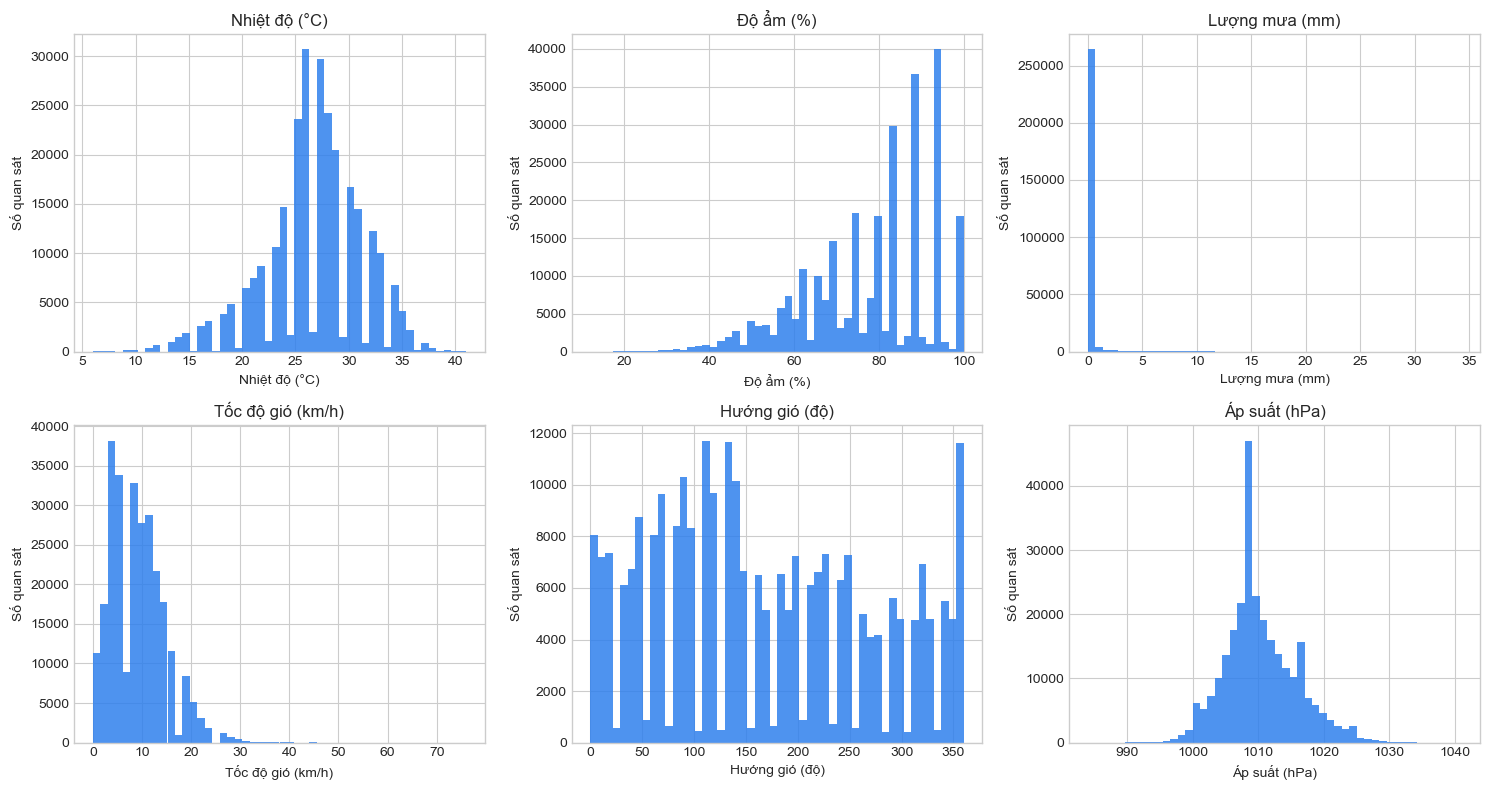

In [9]:
main_cols = ["temp", "rhum", "prcp", "wspd", "wdir", "pres"]
main_cols = [col for col in main_cols if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, main_cols):
    ax.hist(df[col].dropna(), bins=50, color="#2f80ed", alpha=0.85)
    ax.set_title(ten_cot(col))
    ax.set_xlabel(ten_cot(col))
    ax.set_ylabel("Số quan sát")

for ax in axes[len(main_cols):]:
    ax.axis("off")

plt.tight_layout()

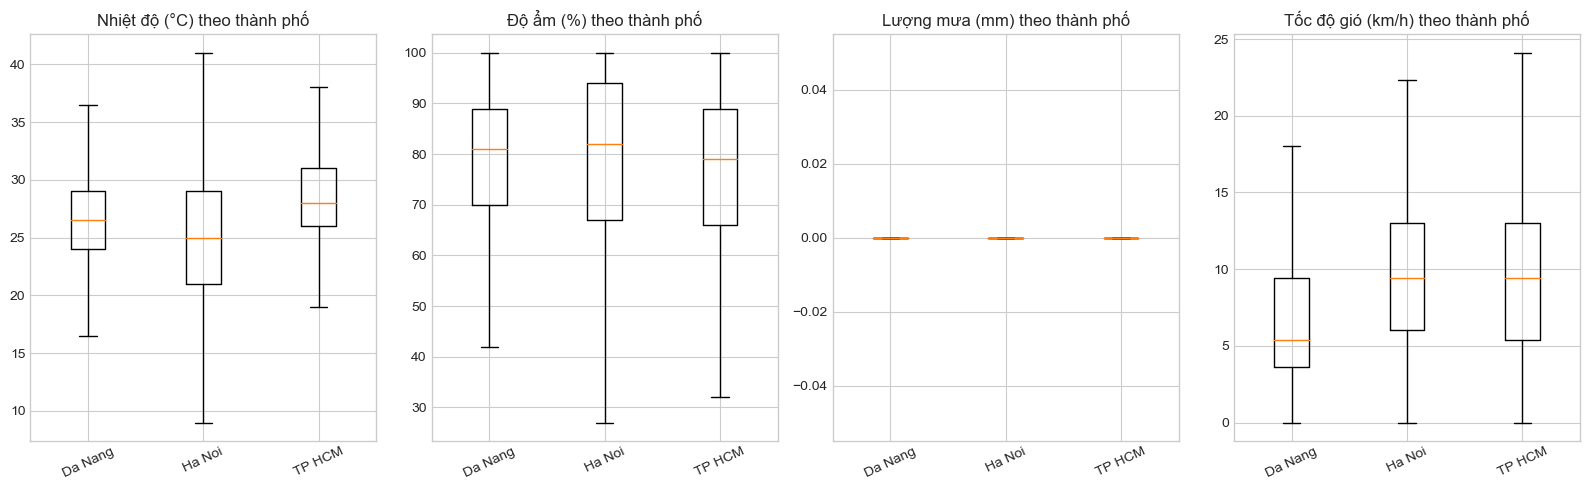

In [10]:
box_cols = ["temp", "rhum", "prcp", "wspd"]
box_cols = [col for col in box_cols if col in df.columns]

fig, axes = plt.subplots(1, len(box_cols), figsize=(4 * len(box_cols), 5))
if len(box_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, box_cols):
    data_by_city = [group[col].dropna() for _, group in df.groupby("city")]
    labels = [city for city, _ in df.groupby("city")]
    ax.boxplot(data_by_city, labels=labels, showfliers=False)
    ax.set_title(f"{ten_cot(col)} theo thành phố")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()

Boxplot giúp so sánh phân phối giữa các thành phố. Đường giữa hộp là trung vị; hộp càng cao thì dữ liệu càng phân tán. Notebook đang ẩn các điểm ngoại lai để biểu đồ dễ đọc hơn.

## 8. Xu hướng theo thời gian

Phần này gom dữ liệu theo tháng để nhìn xu hướng dài hạn. Đây là cách dễ thấy mùa nóng/lạnh, mùa mưa/khô và sự thay đổi độ ẩm theo thời gian.

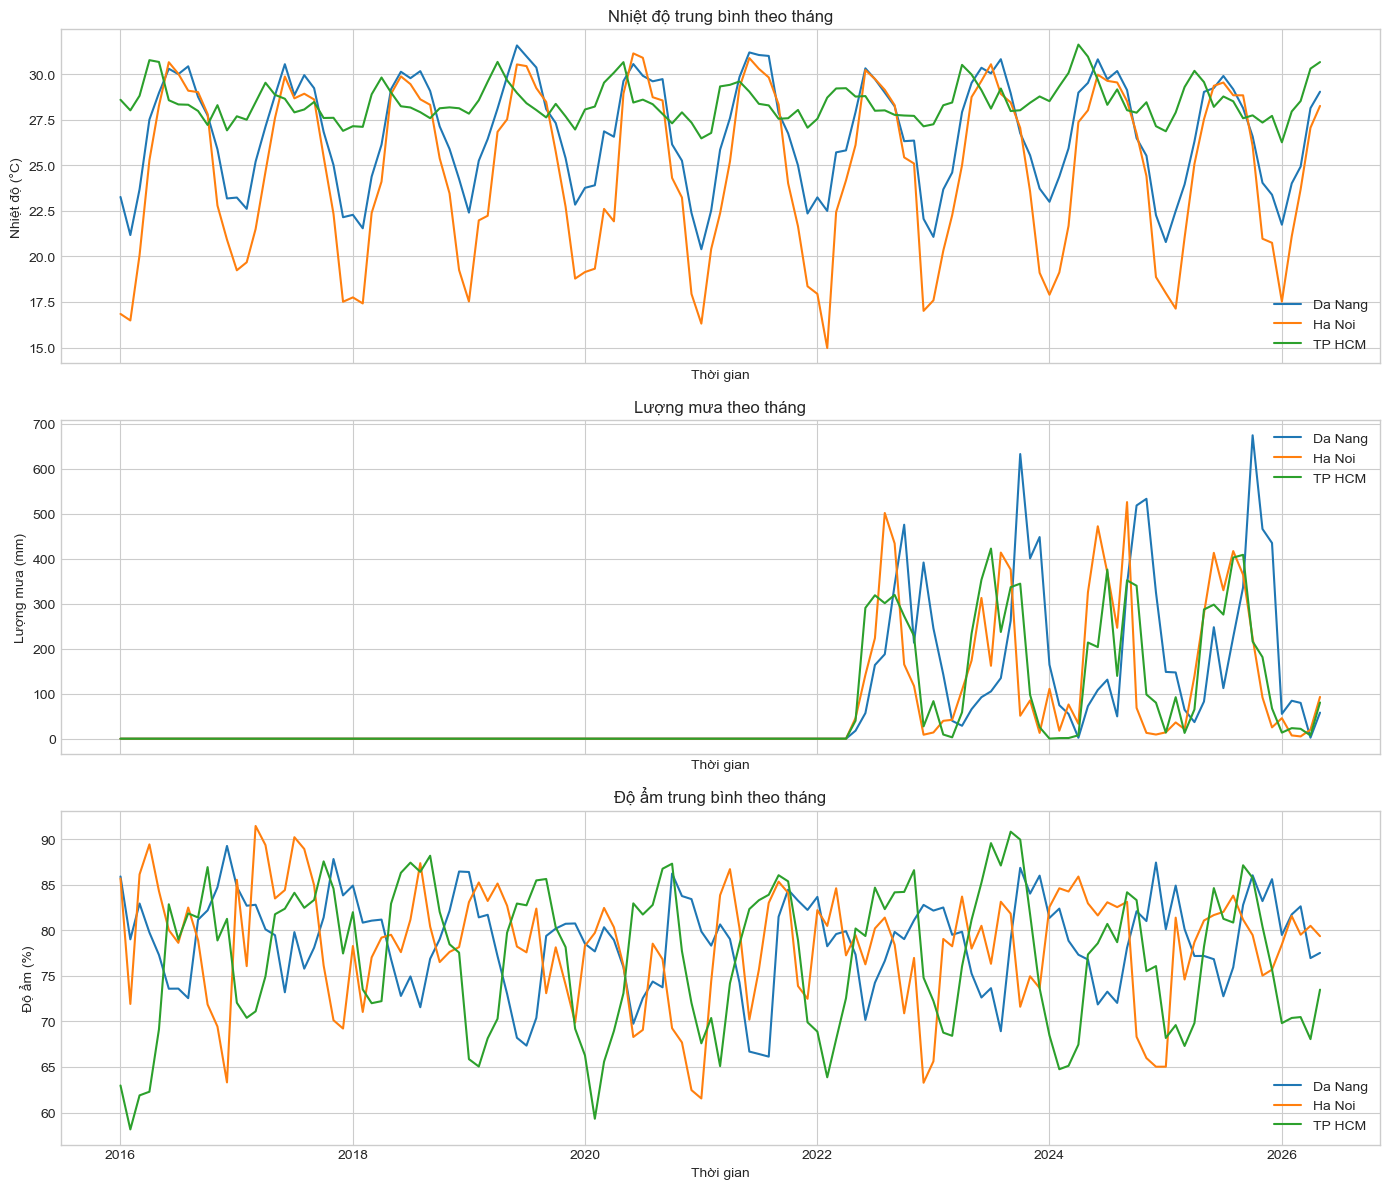

In [11]:
monthly = (
    df.groupby(["city", pd.Grouper(key="time", freq="MS")])
    .agg(temp_mean=("temp", "mean"), prcp_sum=("prcp", "sum"), rhum_mean=("rhum", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for city, city_df in monthly.groupby("city"):
    axes[0].plot(city_df["time"], city_df["temp_mean"], label=city)
    axes[1].plot(city_df["time"], city_df["prcp_sum"], label=city)
    axes[2].plot(city_df["time"], city_df["rhum_mean"], label=city)

axes[0].set_title("Nhiệt độ trung bình theo tháng")
axes[0].set_ylabel("Nhiệt độ (°C)")
axes[1].set_title("Lượng mưa theo tháng")
axes[1].set_ylabel("Lượng mưa (mm)")
axes[2].set_title("Độ ẩm trung bình theo tháng")
axes[2].set_ylabel("Độ ẩm (%)")

for ax in axes:
    ax.legend()
    ax.set_xlabel("Thời gian")

plt.tight_layout()

## 9. Quy luật theo giờ và theo tháng

Nhiệt độ thường có chu kỳ trong ngày và trong năm. Biểu đồ theo giờ giúp thấy lúc nào trong ngày nóng hơn; biểu đồ theo tháng giúp thấy tính mùa vụ. Đây là lý do notebook training tạo thêm các biến `Giờ sin/cos` và `Tháng sin/cos`.

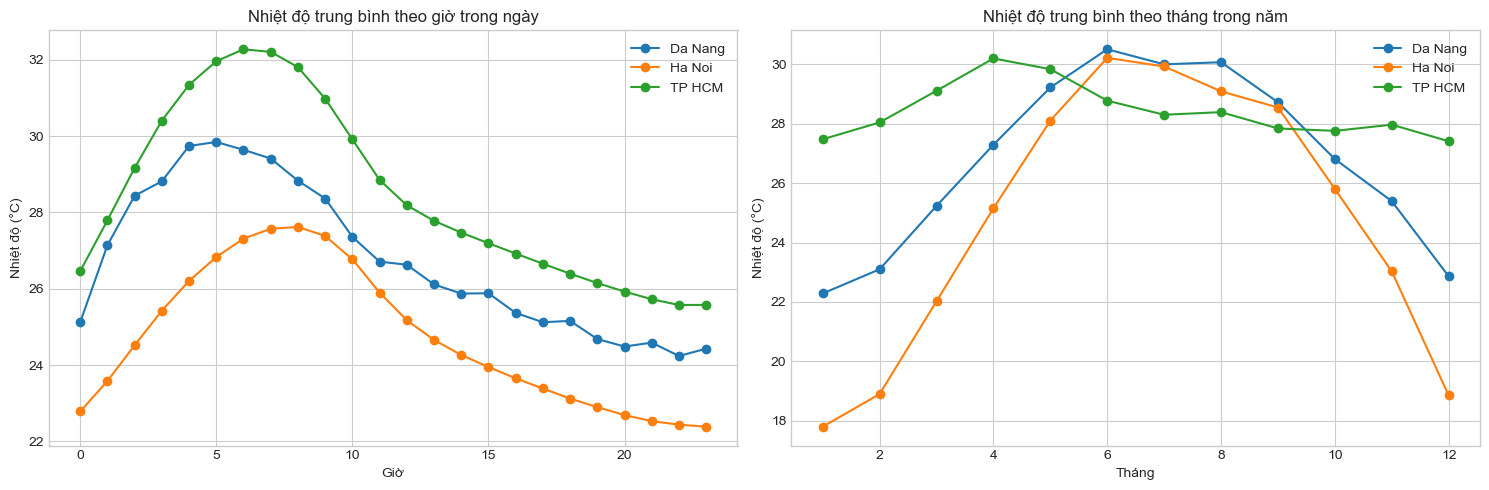

In [12]:
df_time = df.copy()
df_time["hour"] = df_time["time"].dt.hour
df_time["month"] = df_time["time"].dt.month

hourly_profile = df_time.groupby(["city", "hour"], as_index=False).agg(temp=("temp", "mean"), rhum=("rhum", "mean"))
monthly_profile = df_time.groupby(["city", "month"], as_index=False).agg(temp=("temp", "mean"), prcp=("prcp", "sum"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for city, city_df in hourly_profile.groupby("city"):
    axes[0].plot(city_df["hour"], city_df["temp"], marker="o", label=city)

for city, city_df in monthly_profile.groupby("city"):
    axes[1].plot(city_df["month"], city_df["temp"], marker="o", label=city)

axes[0].set_title("Nhiệt độ trung bình theo giờ trong ngày")
axes[0].set_xlabel("Giờ")
axes[0].set_ylabel("Nhiệt độ (°C)")
axes[1].set_title("Nhiệt độ trung bình theo tháng trong năm")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Nhiệt độ (°C)")

for ax in axes:
    ax.legend()

plt.tight_layout()

## 10. Tương quan giữa các biến số

Tương quan nằm trong khoảng từ -1 đến 1. Gần 1 nghĩa là hai biến tăng cùng chiều, gần -1 nghĩa là một biến tăng thì biến kia giảm, gần 0 nghĩa là quan hệ tuyến tính yếu. Tương quan không chứng minh nguyên nhân, nhưng giúp chọn biến và phát hiện quan hệ đáng chú ý.

,Nhiệt độ (°C),Độ ẩm (%),Lượng mưa (mm),Tốc độ gió (km/h),Hướng gió (độ),Áp suất (hPa),Giờ sin,Giờ cos,Tháng sin,Tháng cos
Nhiệt độ (°C),1.000,-0.429,0.020,0.151,0.052,-0.713,0.391,-0.118,-0.229,-0.495
Độ ẩm (%),-0.429,1.000,0.051,-0.229,0.043,-0.022,-0.548,0.173,-0.097,-0.027
Lượng mưa (mm),0.020,0.051,1.000,0.073,0.020,-0.057,0.039,-0.024,-0.088,-0.017
Tốc độ gió (km/h),0.151,-0.229,0.073,1.000,-0.075,-0.082,0.290,-0.198,0.052,-0.087
Hướng gió (độ),0.052,0.043,0.020,-0.075,1.000,-0.065,-0.007,-0.014,-0.150,-0.062
Áp suất (hPa),-0.713,-0.022,-0.057,-0.082,-0.065,1.000,-0.051,0.097,0.312,0.629
Giờ sin,0.391,-0.548,0.039,0.290,-0.007,-0.051,1.000,0.000,0.000,-0.000
Giờ cos,-0.118,0.173,-0.024,-0.198,-0.014,0.097,0.000,1.000,0.000,-0.000
Tháng sin,-0.229,-0.097,-0.088,0.052,-0.150,0.312,0.000,0.000,1.000,-0.000
Tháng cos,-0.495,-0.027,-0.017,-0.087,-0.062,0.629,-0.000,-0.000,-0.000,1.000


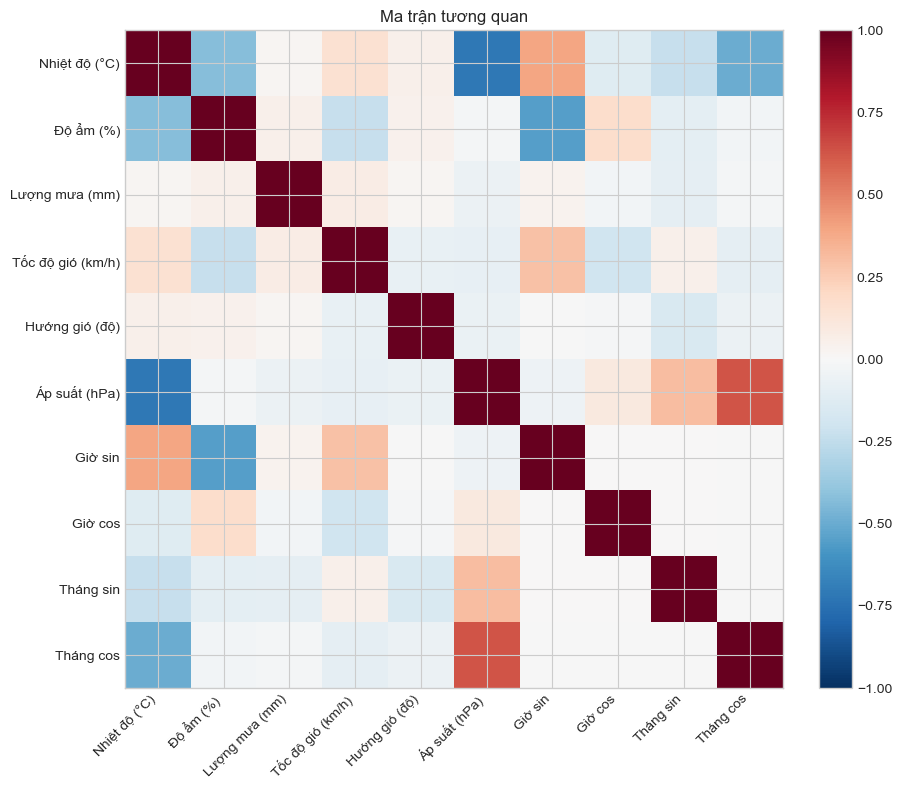

In [13]:
corr_cols = ["temp", "rhum", "prcp", "wspd", "wdir", "pres", "hour_sin", "hour_cos", "month_sin", "month_cos"]
corr_cols = [col for col in corr_cols if col in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
corr_labels = [ten_cot(col) for col in corr_cols]
ax.set_xticklabels(corr_labels, rotation=45, ha="right")
ax.set_yticklabels(corr_labels)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Ma trận tương quan")
plt.tight_layout()

corr.rename(index={col: ten_cot(col) for col in corr.index}, columns={col: ten_cot(col) for col in corr.columns})

## 11. Điều kiện thời tiết phổ biến (`coco`)

`coco` là mã điều kiện thời tiết của Meteostat. Bảng dưới đây giúp xem mã nào xuất hiện nhiều nhất theo từng thành phố. Nếu một mã xuất hiện quá nhiều, dữ liệu có thể đang nghiêng về một loại điều kiện thời tiết nhất định; điều này ảnh hưởng đến khả năng dự báo các trường hợp hiếm như mưa lớn.

In [14]:
if "coco" in df.columns:
    coco_counts = (
        df.groupby(["city", "coco"])
        .size()
        .rename("Số dòng")
        .reset_index()
        .sort_values(["city", "Số dòng"], ascending=[True, False])
    )
    display(coco_counts.rename(columns={"city": "Thành phố", "coco": "Mã thời tiết"}).groupby("Thành phố").head(10))
else:
    print("Không có cột coco trong dữ liệu.")

,Thành phố,Mã thời tiết,Số dòng
3,Da Nang,3,36809
6,Da Nang,7,13536
4,Da Nang,4,10677
5,Da Nang,5,7621
2,Da Nang,2,6263
11,Da Nang,25,5127
10,Da Nang,18,3898
7,Da Nang,8,3666
8,Da Nang,9,1609
9,Da Nang,17,1564


## 12. Gợi ý đọc kết quả

- Nếu `Tỷ lệ thiếu (%)` cao ở biến quan trọng như `Nhiệt độ`, `Độ ẩm`, `Lượng mưa`, nên kiểm tra lại bước tiền xử lý hoặc chiến lược điền thiếu.
- Nếu mỗi thành phố có khoảng thời gian khác nhau, cần cân nhắc khi chia train/test theo thời gian để tránh so sánh không công bằng.
- Các biến `trễ` và `rolling` thường tạo thiếu dữ liệu ở đầu chuỗi; đây là hiện tượng bình thường nếu số lượng thiếu nhỏ.
- Với bài toán dự báo nhiệt độ, nên quan sát kỹ `Nhiệt độ` theo giờ, theo tháng và tương quan với `Độ ẩm`, `Lượng mưa`, `Tốc độ gió`, `Áp suất`.
- Nếu biểu đồ có giá trị quá bất thường, ví dụ nhiệt độ quá cao/thấp so với thực tế, nên quay lại kiểm tra nguồn Meteostat hoặc bước làm sạch dữ liệu.